In [2]:
from dotenv import load_dotenv
import operator
import json
from typing import Annotated, List, TypedDict
from langchain.chat_models import init_chat_model
from langgraph.graph import StateGraph, START, END
# from langgraph.prebuilt import ToolNode, tools_condition

load_dotenv()

True

In [3]:
# State 정의
class GameState(TypedDict):
    year: int
    month: int
    kingdoms: dict
    actions: Annotated[dict, operator.ior]  # 여러 나라의 action을 하나로 묶기 위해서 operator.ior를 사용함
    history: List[str]

In [4]:
# llm 모델 선택
llm = init_chat_model('openai:gpt-4.1-mini', temperature=0.7)

In [5]:
# 위 / 촉 / 오 공통 노드 양식
def kingdom(state: GameState, kingdom_name: str):
    
    recent_six_month = '\n'.join(state['history'][-6:])    # [디벨롭] history를 임베딩 한 다음에 ChromaDB 등에 담음 >>> 각 나라에서 본인과 타 세력의 관계로그를 검색할 수 있게 함으로서 위의 단점을 해소할 수 있으리라 봄.
    kingdoms = state['kingdoms']
    
    # 프롬프트 작성
    # (보완) 다른 세력의 동시간대 action을 넣었어야 하는데, 이를 프롬프트에 넣지 않음
    system_prompt = f'''
    당신은 삼국지 {kingdom_name}나라의 군주입니다.
    목표는 천하통일입니다. 현재 상황을 보고 이번 달에 취할 하나의 행동을 결정하세요.
    행동의 종류는 다음과 같습니다 : 전투(도시 공격 및 수성, 퇴각 등) / 외교(친선, 동맹 등) / 계략(밀정 투입, 방어 시설 붕괴 등) / 내정

    현재 상황: {json.dumps(kingdoms[kingdom_name], ensure_ascii=False)}
    과거 역사: {recent_six_month}

    **어떠한 부연 설명도 하지 말고, 반드시 아래의 JSON 형식으로만 답변을 출력하세요.**
    {{
        "action_type": "[전투, 외교, 계략, 내정 중 선택 (최대 2개까지 선택 가능)]",
        "action_details": "[현재 상황을 반영하여 군주로서 내리는 구체적인 지시를 하나의 문장으로 작성]"
    }}
    
    '''
    
    # llm 모델을 통해 actions를 생성하기
    response = llm.invoke([{'role': 'system', 'content': system_prompt}, 
                           {'role': 'user', 'content': '이번 달 우리의 전략은 무엇입니까?'}])
    
    result_data = json.loads(response.content)
    action_text = result_data.get("action_details", "")

    # 사용자가 해당 세력이 어떠한 행동을 했는지 확인할 수 있도록 print 구문 출력
    print(f'{kingdom_name}나라의 행동 : {action_text}')
    
    # 해당 나라의 행동을 state에 저장
    return {'actions': {kingdom_name: action_text}}

In [6]:
# 플레이어 세력 행동
def player_kingdom(state: GameState, kingdom_name: str):

    recent_six_month = '\n'.join(state['history'][-6:])
    kingdoms = state['kingdoms']
    
    print(f"[최근 역사]\n{recent_six_month}\n")
    print(f"[{kingdom_name} 현재 상황]\n{json.dumps(kingdoms[kingdom_name], ensure_ascii=False)}\n")

    print("[행동 지시]\n")
    print("전투(도시 공격 및 수성, 퇴각 등) / 외교(친선, 동맹 등) / 계략(밀정 투입, 방어 시설 붕괴 등) / 내정 중 하나의 지시를 구체적으로 내려주세요.\n")
    print("(예: 조운을 합비로 보내어 위나라를 공격한다. / 내정에 힘써 금과 곡식을 모은다.)")
    
    # LLM 대신 파이썬 내장 input()으로 사용자 입력 대기
    action_text = input(f"{kingdom_name}나라의 행동 입력 : ")

    print(f"{kingdom_name}나라(플레이어)의 행동 : {action_text}")
    
    # 심판 노드가 읽을 수 있도록 기존과 동일한 딕셔너리 구조로 반환
    return {'actions': {kingdom_name: action_text}}

In [7]:
# 세 세력 행동 후 결과를 결정할 심판 노드
def judge(state: GameState):
    
    actions = state['actions']
    kingdoms = state['kingdoms']
    
    system_prompt = f'''
    당신은 삼국지의 심판입니다. 아래 세 나라의 행동에 대해 결과를 판단하세요.
    
    [전투 및 사건 판정 기준]
    1. 자원의 증감: 전투를 치르면 병사와 금_곡식이 감소하고, 내정을 하면 증가합니다.
    2. 자원 우위:'금_곡식'의 상태는 보급과 직결됩니다. 보급이 부족한 세력은 전투에서 승리하기 매우 어렵습니다.
    3. 장수 변수:자원이 다소 부족하더라도 압도적으로 강력한 장수가 있다면 전황을 뒤집을 수 있으며, 적장을 포획(general_capture)할 확률이 높아집니다.
    4. 수성의 이점: 수성이 공성보다 유리합니다. 다만 투석기나 충차를 동원하면, 도시 함락(city_capture)할 확률이 높아집니다.
    5. 전략적 상성: 세 나라의 '행동'을 종합적으로 분석하세요. 한 세력이 두 세력으로부터 동시에 공격받거나, 공격을 나간 사이 본진을 기습당하는 경우 방어력이 급격히 하락한 것으로 간주하세요.
    
    [현재 세력 상태]
    {json.dumps(kingdoms, ensure_ascii=False)}
    
    [각 나라의 행동]
    {json.dumps(actions, ensure_ascii=False)}
    
    **결과는 반드시 아래 JSON 형식으로만 답변하세요:**
    {{
        "description": "세 세력이 행동한 결과에 대한 상세한 역사적 묘사 (한 문장)",
        "events": [
        {{
            "type": "city_capture",
            "from": "도시를 빼앗긴 세력 (위, 촉, 오)", 
            "to": "도시를 얻은 세력 (위, 촉, 오)", 
            "target_city": "대상 도시명"
        }},
        {{
            "type": "general_capture",
            "from": "장수가 원래 소속된 세력 (위, 촉, 오)",
            "to": "장수를 포획한 세력 (위, 촉, 오)",
            "target_general": "포로가 된 장수 이름"
        }},
        {{
            "type": "military_change",
            "kingdom": "세력명 (위, 촉, 오)",
            "status": "다음 중 하나 선택: 매우 많음, 많음, 보통, 적음, 매우 적음"
        }},
        {{
            "type": "resource_change",
            "kingdom": "세력명 (위, 촉, 오)",
            "status": "다음 중 하나 선택: 매우 풍족, 풍족, 보통, 부족, 매우 부족"
        }}
        ]
    }}

    '''
    # [디벨롭] llm에 의존하지 않고, all_star_lineup.jsonl에 있는 데이터를 기반으로 전투 승패를 가르는 tool을 만들었다면 더 좋았을 듯.

    # 여기서 LLM이 판정 결과를 생성
    response = llm.invoke(system_prompt)
    
    result_data = json.loads(response.content)
    result_text = result_data['description']
    events = result_data.get('events', [])

    # 세력의 상태값 변화시키기
    for event in events:
        event_type = event.get('type')

        if event_type == 'city_capture':
            loser = event['from']
            winner = event['to']
            city = event['target_city']

            if city in kingdoms[loser]['보유_도시']:
                kingdoms[loser]['보유_도시'].remove(city)
                if city not in kingdoms[winner]['보유_도시']:
                    kingdoms[winner]['보유_도시'].append(city)
        
        if event_type == 'general_capture':
            loser = event['from']
            winner = event['to']
            general = event['target_general']

            if general in kingdoms[loser]['휘하_장수']:
                kingdoms[loser]['휘하_장수'].remove(general)
                if general not in kingdoms[winner]['포로']:
                    kingdoms[winner]['포로'].append(general)

        if event_type == 'military_change':
            who = event['kingdom']
            status = event['status']
            kingdoms[who]['병사'] = status

        if event_type == 'resource_change':
            who = event['kingdom']
            status = event['status']
            kingdoms[who]['금_곡식'] = status


    # 결과 문장을 history에 추가
    new_history = state['history'] + [f"[{state['year']}년 {state['month']}개월] {result_text}"]
    # 사용자도 볼 수 있게 출력
    print(f'[{state['year']}년 {state['month']}개월] {result_text}')

    # 시스템 업데이트
    new_month = state['month'] + 1
    new_year = state['year']
    if new_month > 12:
        new_month = 1
        new_year += 1
    
    return {
        'year': new_year,
        'month': new_month,
        'kingdoms' : kingdoms,
        'history': new_history,
        'actions': {}, # 다음 턴을 위해 행동 초기화
    }

In [8]:
# 0년부터 시작해 n년이 되면 종료되도록 함수 정의

def check_limit(state: GameState):
    if state['year'] >= 1:
        return END
    else:
        return ['위', '촉', '오']


촉나라를 선택했습니다.



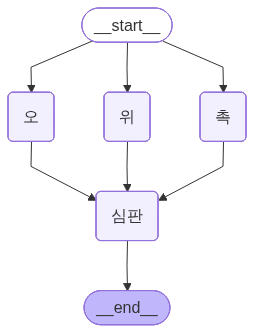

In [9]:
builder = StateGraph(GameState)
# tool_node = ToolNode(tools)

# 플레이할 국가 선택
while True:
    user_choice = input("플레이할 세력을 선택하세요 [위, 촉, 오] : ").strip()
    if user_choice in ['위', '촉', '오']:
        break
    print("'위', '촉', '오' 중 하나를 입력해주세요.")

print(f"\n{user_choice}나라를 선택했습니다.\n")

builder = StateGraph(GameState)

builder.add_node('위', lambda x: player_kingdom(x, '위') if user_choice == '위' else kingdom(x, '위'))
builder.add_node('촉', lambda x: player_kingdom(x, '촉') if user_choice == '촉' else kingdom(x, '촉'))
builder.add_node('오', lambda x: player_kingdom(x, '오') if user_choice == '오' else kingdom(x, '오'))
builder.add_node("심판", judge)

builder.add_edge(START, '위')
builder.add_edge(START, '촉')
builder.add_edge(START, '오')

builder.add_edge('위', '심판')
builder.add_edge('촉', '심판')
builder.add_edge('오', '심판')

builder.add_conditional_edges('심판', check_limit)

graph = builder.compile()
graph


In [ ]:
initial_state = {
    "year": 0,
    "month": 1,
    "kingdoms": {
        "위": {
            "보유_도시": ["낙양", "업", "장안", "허창", "진류", "양양", "합비"],
            "휘하_장수": ["조조", "사마의", "순욱", "곽가", "가후", "하후돈", "하후연", "장료", "서황", "장합", "조인", "허저"],
            "포로": [],
            "병사": "매우 많음",
            "금_곡식": "풍족"
        },
        "촉": {
            "보유_도시": ["성도", "한중", "강주", "자동"],
            "휘하_장수": ["유비", "제갈량", "관우", "장비", "조운", "마초"],
            "포로": [],
            "병사": "보통",
            "금_곡식": "부족"
        },
        "오": {
            "보유_도시": ["건업", "오창", "시상", "회계"],
            "휘하_장수": ["손권", "주유", "노숙", "육손", "여몽", "감녕"],
            "포로": [],
            "병사": "많음",
            "금_곡식": "매우_풍족"
        }
    },
    "actions": {},
    "history": []
}

# 실행
final_state = graph.invoke(initial_state)

[최근 역사]


[촉 현재 상황]
{"보유_도시": ["성도", "한중", "강주", "자동"], "휘하_장수": ["유비", "제갈량", "관우", "장비", "조운", "마초"], "포로": [], "병사": "보통", "금_곡식": "부족"}

[행동 지시]

전투(도시 공격 및 수성, 퇴각 등) / 외교(친선, 동맹 등) / 계략(밀정 투입, 방어 시설 붕괴 등) / 내정 중 하나의 지시를 구체적으로 내려주세요.

(예: 조운을 합비로 보내어 위나라를 공격한다. / 내정에 힘써 금과 곡식을 모은다.)
위나라의 행동 : 풍족한 자원을 활용해 병력을 집중하여 손권의 주요 도시인 오를 공격하여 영토 확장을 추진하라.
오나라의 행동 : 조조와의 동맹을 추진하여 북부의 위협을 분산시키고, 손권과 주유에게 외교 사절을 보내 강동 지역의 안정과 협력을 강화하라.
촉나라(플레이어)의 행동 : 
[0년 1개월] 위가 풍족한 자원을 바탕으로 오의 주요 도시 오를 공격하여 성공적으로 점령하였고, 오는 조조와의 동맹 추진으로 북부 위협 분산과 강동 지역 안정에 노력하여 내부 결속을 강화하였으며, 촉은 별다른 행동이 없어 자원과 병력에 큰 변화가 없었다.
[최근 역사]
[0년 1개월] 위가 풍족한 자원을 바탕으로 오의 주요 도시 오를 공격하여 성공적으로 점령하였고, 오는 조조와의 동맹 추진으로 북부 위협 분산과 강동 지역 안정에 노력하여 내부 결속을 강화하였으며, 촉은 별다른 행동이 없어 자원과 병력에 큰 변화가 없었다.

[촉 현재 상황]
{"보유_도시": ["성도", "한중", "강주", "자동"], "휘하_장수": ["유비", "제갈량", "관우", "장비", "조운", "마초"], "포로": [], "병사": "보통", "금_곡식": "부족"}

[행동 지시]

전투(도시 공격 및 수성, 퇴각 등) / 외교(친선, 동맹 등) / 계략(밀정 투입, 방어 시설 붕괴 등) / 내정 중 하나의 지시를 구체적으로 내려주세요.

(예: 조운을 합비로 보내어 위나라를 공격한다. 

In [ ]:
# with open('../data/three_kingdoms_status.json', 'r', encoding='utf-8') as f:
#     kingdoms_default = json.load(f)

# initial_state = {
#     "year": 0,
#     "month": 1,
#     "kingdoms": kingdoms_default,
#     "actions": {},
#     "history": []
# }


### Streamlit 구현 전략
- 매달 위,촉,오의 행동과 이에 대한 결과값 출력 (이전 기록은 지우면서)
- 과거 로그는 특정 버튼을 누르면 창이 떠서 스크롤해서 볼 수 있도록